# Day 19

---


In [1]:
import grama as gr
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
DF = gr.Intention()

# Set figure options
plt.rcParams['figure.figsize'] = [6, 6] # Need square aspect ratio for gradients to appear normal
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower


## Example: Multivariate Gaussian

Let's look at three cases:

- Isotonic ($\Sigma = \sigma^2 I$)
- Uncorrelated, different variances
- Correlated, same variances
- Correlated, different variances

$$\text{corr} = \frac{\text{Cov}[X, Y]}{\sigma_X \sigma_Y}$$


Estimated runtime: 0.0000 sec


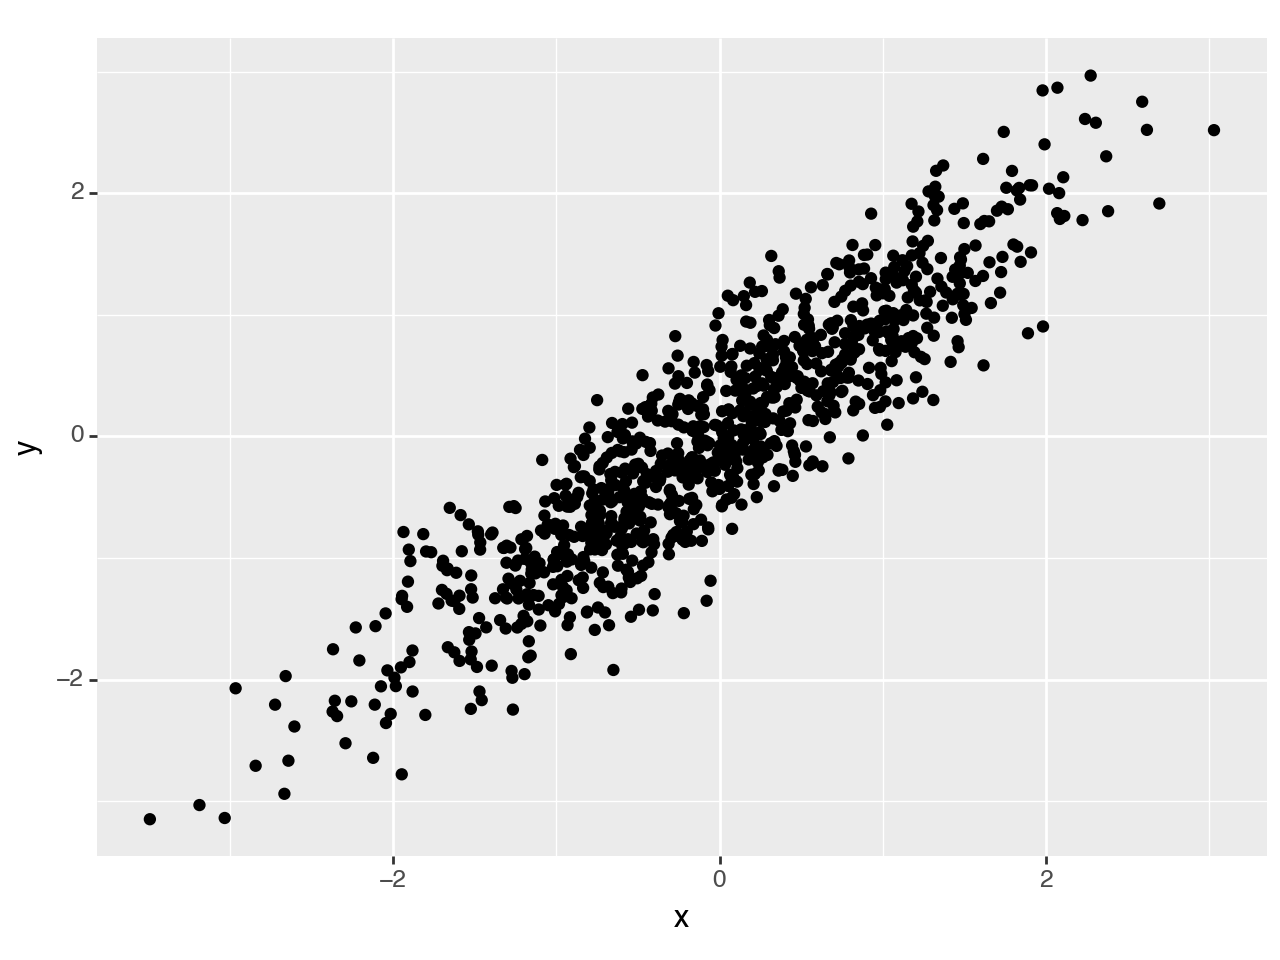

<Figure Size: (640 x 480)>

In [15]:
md_gauss = (
    gr.Model("2d Gaussian")
    >> gr.cp_marginals(
        x=gr.marg_mom("norm", mean=0, sd=1),
        y=gr.marg_mom("norm", mean=0, sd=1),
    )
    >> gr.cp_copula_gaussian(
        df_corr=gr.df_make(
            var1="x", var2="y", corr=0.9,
        )
    )
)

(
    md_gauss
    >> gr.ev_sample(df_det="nom", skip=True, n=1000)
    >> gr.ggplot(gr.aes("x", "y"))
    + gr.geom_point()
    # + gr.coord_cartesian(xlim=(-10, +10), ylim=(-10, +10))
)

### Joint Density


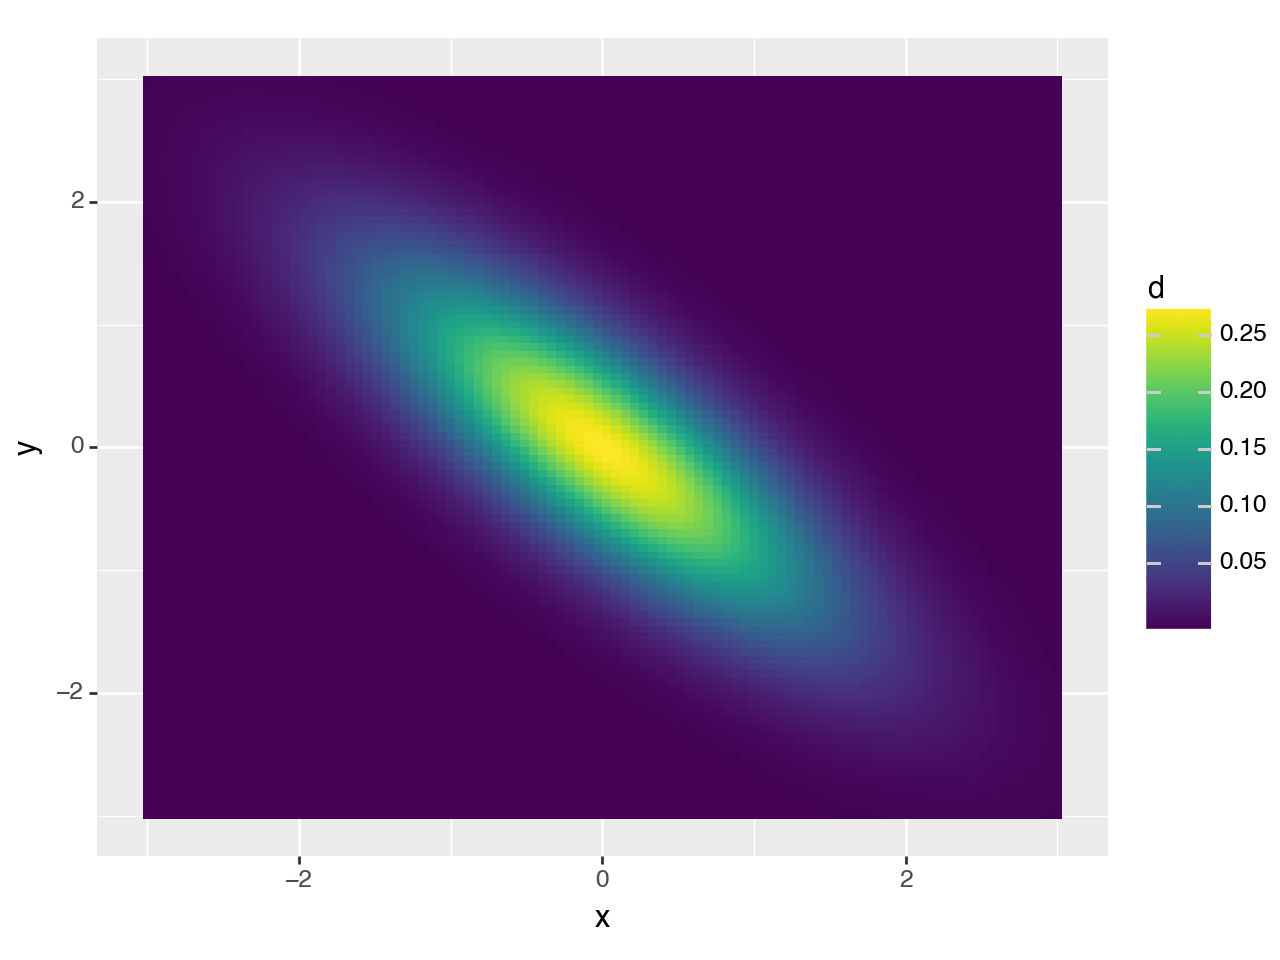

<Figure Size: (640 x 480)>

In [9]:
# Evaluate the joint density
df_2d = gr.df_grid(
    x=gr.linspace(-3, +3, 100),
    y=gr.linspace(-3, +3, 100),
)
df_2d['d'] = md_gauss.density.d(df_2d[["x", "y"]])

# Plot
(
    df_2d
    >> gr.ggplot(gr.aes("x", "y"))
    + gr.geom_tile(gr.aes(fill="d"))
)

### Marginals

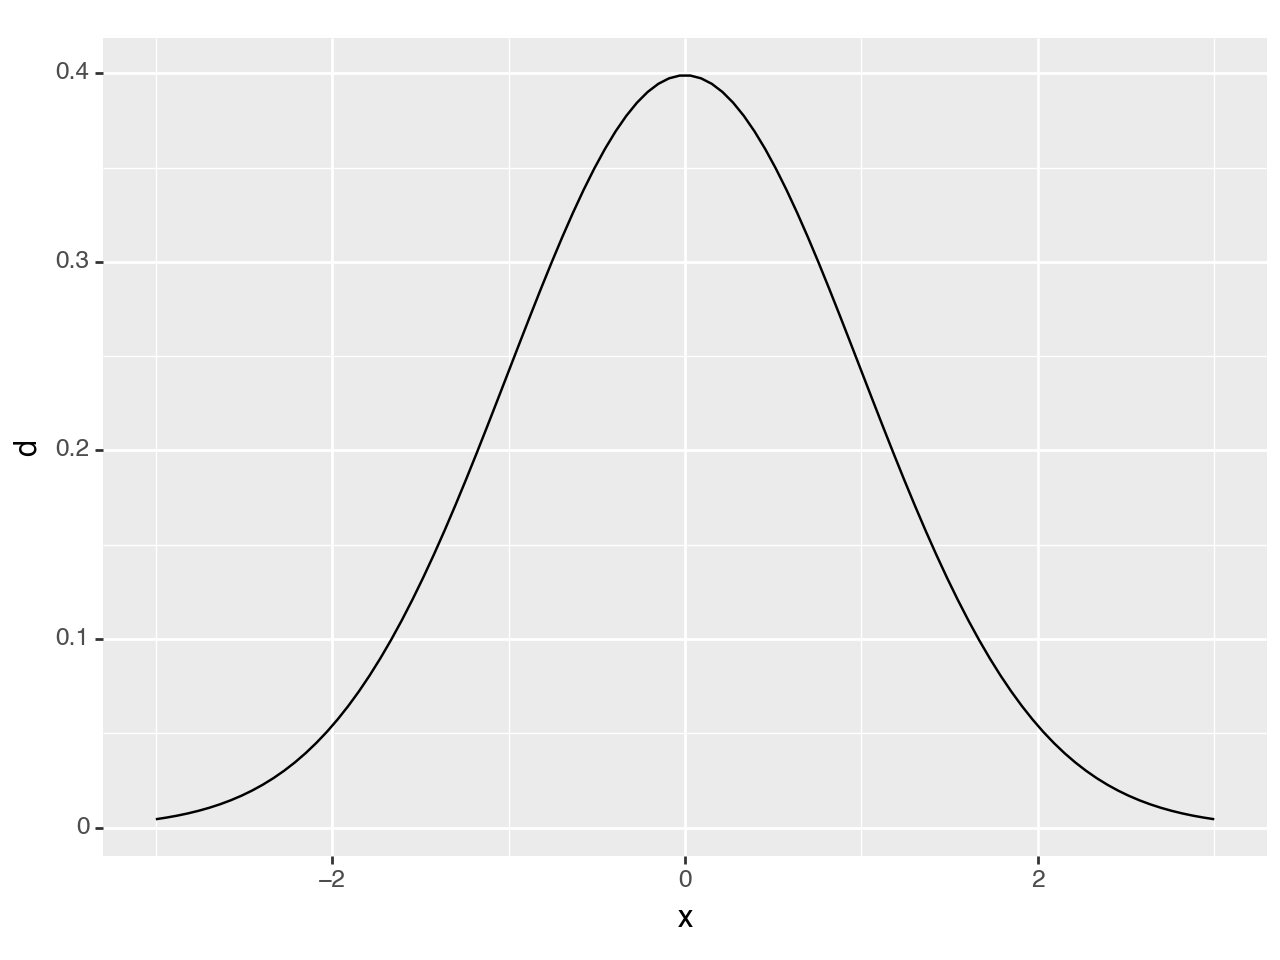

<Figure Size: (640 x 480)>

In [4]:
(
    gr.df_make(x=gr.linspace(-3, +3, 100))
    >> gr.tf_mutate(
        d=md_gauss.density.marginals["x"].d(DF.x)
    )

    >> gr.ggplot(gr.aes("x", "d"))
    + gr.geom_line()
)

## Sample vs Population

In [5]:
(
    md_gauss # corr = 0.5 exactly
    >> gr.ev_sample(df_det="nom", skip=True, n=1000)
    >> gr.tf_summarize(
        corr_sample=gr.corr(DF.x, DF.y)
    )
)

Estimated runtime: 0.0000 sec


,corr_sample
0,-0.031187


Note that, due to sampling, the sample correlation is not exactly equal to the population correlation.

Reminder: This is why we use confidence intervals to describe the precision of our estimate.

### Important caveat: Correlation is **not** a slope!

![](https://upload.wikimedia.org/wikipedia/commons/d/d4/Correlation_examples2.svg)

This is a super-important figure. The value above each panel gives the correlation $\rho_{X,Y}$ for that set of data. Note that correlation is not a slope! Rather, it is a measure of how close to linear a trend is. The less variable that trend, the close to $\pm1$ is $\rho$. Also, nonlinear trends can be entirely missed by $\rho$.
